# Kozachenko-Leonenko estimate for Shannon entropies

In [7]:
import numpy as np
from scipy.spatial import cKDTree
from scipy.special import digamma
import math

def theoretical_gaussian_entropy(sigma, d=1):
    """
    Tính entropy lý thuyết của phân bố Gauss d-chiều độc lập.
    Kết quả tính bằng đơn vị nats (cơ số e).
    """
    return 0.5 * d * math.log(2 * math.pi * math.e * sigma**2)

def kl_entropy_estimator(data, k=3):
    """
    Ước lượng Shannon Entropy bằng thuật toán Kozachenko-Leonenko (1987).
    Tham chiếu: Công thức (20) trong bài báo KSG (2004).
    """
    n, d = data.shape
    
    # Sử dụng KDTree với p=np.inf (Maximum norm / Chebyshev distance)
    # để hệ số hình học c_d = 1, do đó log(c_d) = 0.
    tree = cKDTree(data)
    
    # Tìm khoảng cách đến k láng giềng gần nhất.
    # Chọn k+1 vì thuật toán sẽ trả về chính điểm đó ở vị trí đầu tiên (khoảng cách = 0).
    distances, _ = tree.query(data, k=k+1, p=np.inf)
    
    # Bán kính đến điểm láng giềng thứ k
    r = distances[:, k]
    
    # epsilon là bề rộng của hình hộp bao quanh (gấp đôi bán kính)
    epsilons = 2 * r
    
    # Xử lý ngoại lệ: Tránh log(0) nếu có các điểm trùng lặp hoàn toàn
    epsilons = np.maximum(epsilons, np.finfo(float).eps)
    
    # Công thức cốt lõi (Eq. 20)
    term1 = -digamma(k)
    term2 = digamma(n)
    term3 = (d / n) * np.sum(np.log(epsilons))
    
    h_est = term1 + term2 + term3
    
    return h_est

if __name__ == "__main__":
    # 1. Cấu hình bài toán giả định
    np.random.seed(42)
    n_samples = 5000
    dim = 1
    true_sigma = 1.0
    
    # 2. Sinh dữ liệu từ Ground Truth (Phân bố chuẩn)
    # Reshape thành ma trận cột (n_samples, dim)
    data_gaussian = np.random.normal(0, true_sigma, size=(n_samples, dim))
    
    # 3. Tính toán và so sánh
    k_neighbors = 3
    
    h_theoretical = theoretical_gaussian_entropy(true_sigma, dim)
    h_estimated = kl_entropy_estimator(data_gaussian, k=k_neighbors)
    error = abs(h_theoretical - h_estimated)
    
    print(f"--- ĐÁNH GIÁ THUẬT TOÁN KL ENTROPY ---")
    print(f"Số lượng mẫu (N): {n_samples}")
    print(f"Số chiều (d): {dim}")
    print(f"Tham số k: {k_neighbors}\n")
    print(f"Entropy Lý thuyết (Ground Truth): {h_theoretical:.5f} nats")
    print(f"Entropy Ước lượng (KL k-NN):      {h_estimated:.5f} nats")
    print(f"Sai số tuyệt đối:                 {error:.5f} nats")

--- ĐÁNH GIÁ THUẬT TOÁN KL ENTROPY ---
Số lượng mẫu (N): 5000
Số chiều (d): 1
Tham số k: 3

Entropy Lý thuyết (Ground Truth): 1.41894 nats
Entropy Ước lượng (KL k-NN):      1.41531 nats
Sai số tuyệt đối:                 0.00362 nats


--- MÔ PHỎNG KSG TRÊN KHÔNG GIAN 3D ---
Toa do tam i: (2.28, -0.85, 0.52)
Khoang cach eps_half (toi lang gieng thu 3): 0.9531
So diem roi vao bong chieu: n_x = 7, n_y = 54, n_z = 62



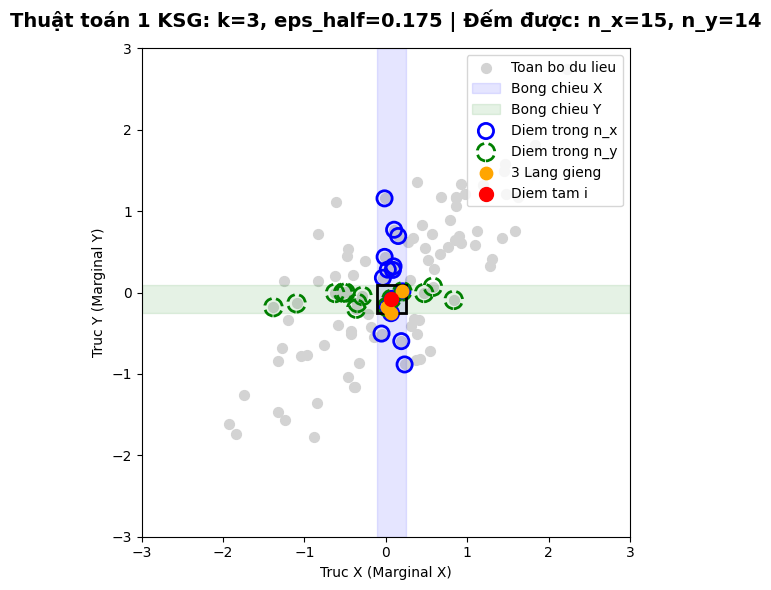

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def generate_correlated_data_2d(n_samples=100):
    """Tao du lieu 2D co tuong quan de thay ro su thay doi mat do."""
    mean = [0, 0]
    cov = [[1.0, 0.8], 
           [0.8, 1.0]]
    return np.random.multivariate_normal(mean, cov, n_samples)

def simulate_ksg_3d(k=3):
    """Mo phong co che KSG tren khong gian 3D va in log."""
    print("--- MÔ PHỎNG KSG TRÊN KHÔNG GIAN 3D ---")
    data_3d = np.random.multivariate_normal([0, 0, 0], np.eye(3), 100)
    
    # Chon mot diem trung tam
    center_idx = 50
    center = data_3d[center_idx]
    
    # Tinh chuan cuc dai (Chebyshev distance)
    dists = np.max(np.abs(data_3d - center), axis=1)
    
    # Tim khoang cach toi lang gieng thu k (bo qua chinh no = 0)
    sorted_dists = np.sort(dists)
    eps_half = sorted_dists[k]
    
    # Chieu xuong 3 truc va dem so diem (nghiem ngat < eps_half)
    nx = np.sum(np.abs(data_3d[:, 0] - center[0]) < eps_half)
    ny = np.sum(np.abs(data_3d[:, 1] - center[1]) < eps_half)
    nz = np.sum(np.abs(data_3d[:, 2] - center[2]) < eps_half)
    
    print(f"Toa do tam i: ({center[0]:.2f}, {center[1]:.2f}, {center[2]:.2f})")
    print(f"Khoang cach eps_half (toi lang gieng thu {k}): {eps_half:.4f}")
    print(f"So diem roi vao bong chieu: n_x = {nx}, n_y = {ny}, n_z = {nz}\n")

def visualize_ksg_2d(k=3):
    """Truc quan hoa co che hinh hoc KSG 1 tren mat phang 2D."""
    # 1. TAO DU LIEU
    np.random.seed(42)
    data = generate_correlated_data_2d(100)
    
    # Chon diem gan goc toa do nhat de hinh anh chieu dep nhat
    center_idx = np.argmin(np.sum(data**2, axis=1))
    center = data[center_idx]
    x_i, y_i = center[0], center[1]
    
    # 2. KHONG GIAN TONG (JOINT SPACE)
    # Tinh chuan cuc dai
    dists = np.max(np.abs(data - center), axis=1)
    
    # Khoang cach toi lang gieng thu k
    sorted_dists = np.sort(dists)
    eps_half = sorted_dists[k]
    
    # Tim k lang gieng nam trong hop
    k_neighbors_mask = (dists <= eps_half) & (dists > 0)
    k_neighbors = data[k_neighbors_mask]
    
    # 3. KHONG GIAN BIEN (MARGINAL SPACE) - CHIEU VA DEM
    # Mask diem thoa man dieu kien chieu (khoang cach chieu < eps_half)
    nx_mask = np.abs(data[:, 0] - x_i) < eps_half
    ny_mask = np.abs(data[:, 1] - y_i) < eps_half
    
    nx = np.sum(nx_mask)
    ny = np.sum(ny_mask)
    
    # 4. TRUC QUAN HOA (MATPLOTLIB)
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Ve toan bo du lieu (mau xam)
    ax.scatter(data[:, 0], data[:, 1], color='lightgray', s=50, label='Toan bo du lieu')
    
    # Ve dai bang chieu tren truc X (xanh duong nhat)
    ax.axvspan(x_i - eps_half, x_i + eps_half, color='blue', alpha=0.1, label='Bong chieu X')
    
    # Ve dai bang chieu tren truc Y (xanh la nhat)
    ax.axhspan(y_i - eps_half, y_i + eps_half, color='green', alpha=0.1, label='Bong chieu Y')
    
    # Highlight cac diem thuoc bong chieu X
    ax.scatter(data[nx_mask, 0], data[nx_mask, 1], 
               facecolor='none', edgecolor='blue', s=120, linewidth=2, label='Diem trong n_x')
               
    # Highlight cac diem thuoc bong chieu Y
    ax.scatter(data[ny_mask, 0], data[ny_mask, 1], 
               facecolor='none', edgecolor='green', s=160, linewidth=2, linestyle='--', label='Diem trong n_y')
               
    # Ve hop vuong eps_half
    rect = plt.Rectangle((x_i - eps_half, y_i - eps_half), 2*eps_half, 2*eps_half, 
                         fill=False, edgecolor='black', linewidth=2, zorder=5)
    ax.add_patch(rect)
    
    # Ve k lang gieng (mau cam)
    ax.scatter(k_neighbors[:, 0], k_neighbors[:, 1], color='orange', s=80, zorder=6, label=f'{k} Lang gieng')
    
    # Ve diem tam i (mau do)
    ax.scatter(x_i, y_i, color='red', s=100, zorder=7, label='Diem tam i')
    
    # Can chinh do thi
    ax.set_aspect('equal')
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_xlabel('Truc X (Marginal X)')
    ax.set_ylabel('Truc Y (Marginal Y)')
    
    # Tieu de the hien thong so KSG
    ax.set_title(f"Thuật toán 1 KSG: k={k}, eps_half={eps_half:.3f} | Đếm được: n_x={nx}, n_y={ny}", 
                 fontsize=14, fontweight='bold', pad=15)
    ax.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Chay mo phong log 3D
    simulate_ksg_3d(k=3)
    
    # Chay truc quan hoa 2D
    visualize_ksg_2d(k=3)

> **Triết lý Max-Norm trong Ước lượng Không gian Đa chiều**
> Thay vì đo khoảng cách độc lập trên các trục có mật độ giãn nở khác nhau (nguồn gốc sinh ra sai số lệch pha), hãy dùng chuẩn cực đại (Max-norm) để "đóng băng" một khung tham chiếu siêu lập phương duy nhất cho toàn hệ thống. Bằng cách chiếu ranh giới cố định này xuống các không gian biên và chuyển đổi bài toán từ "đo khoảng cách" sang "đếm số điểm", ta ép mọi sai số hệ thống phải đồng bộ và tự động triệt tiêu lẫn nhau một cách tuyệt đối.
>
> # 🚀 GHI CHÚ MỞ RỘNG: DI SẢN CỦA TRIẾT LÝ MAX-NORM (KSG) TRONG KHOA HỌC DỮ LIỆU HIỆN ĐẠI

Triết lý "cố định ranh giới đa chiều, đếm hạt biên để triệt tiêu sai số" của KSG đã vượt khỏi khuôn khổ của Entropy để trở thành lõi vận hành cho các bài toán phân tích phi tuyến phức tạp:

* **Phân tích Nhân quả với Transfer Entropy (TE):** Để đo lường chiều truyền thông tin giữa hai chuỗi thời gian, toán học sử dụng Conditional Mutual Information (CMI). Triết lý chiếu hộp KSG được áp dụng hoàn hảo ở đây: Dùng một siêu lập phương duy nhất trong không gian $(X, Y, Z)$ chiếu xuống các không gian con để đếm điểm, giúp ước lượng chính xác kết nối nhân quả của hệ động lực mà không bị nhiễu nền làm sai lệch.
* **Dung hợp Đặc trưng Dị thể (Heterogeneous Feature Fusion):** Khi thiết kế các kiến trúc AI lai (ví dụ: kết hợp đặc trưng miền thời - tần số với các đặc trưng phi tuyến nhạy cảm như số mũ Lyapunov hay chiều Fractal), không gian pha đa chiều sẽ giãn nở cực kỳ bất đối xứng. Khung tham chiếu Max-norm đóng vai trò như một bộ neo giữ độ đo, đảm bảo các đặc trưng vi mô mang thông tin cốt lõi không bị "nuốt chửng" bởi các đặc trưng tuyến tính có phương sai lớn.
* **Tái tạo Không gian Pha Kháng nhiễu (Robust Phase Space Reconstruction):** Khi phân tích các chuỗi tín hiệu sinh lý phi dừng chứa mật độ nhiễu chuyển động cao (như các bản ghi PPG trong tập dữ liệu thực nghiệm PhysDrive 2025), sự lỳ lợm của KSG giúp việc tính toán trễ thời gian $\tau$ không bị "ảo giác" bởi các điểm kỳ dị, đảm bảo bộ hút hỗn mang (chaos attractor) được bung mở chính xác làm đầu vào cho các mạng Neural.
* **Explainable AI (XAI) theo Lý thuyết Thông tin:** Để diễn giải các mô hình hộp đen, các kỹ thuật như SHAP hoặc LIME đang ngày càng ứng dụng các bộ ước lượng nền tảng KSG. Việc đo lường lượng thông tin đóng góp của từng tập con đặc trưng (feature subsets) vào dự đoán của mô hình được tính toán mượt mà hơn, không bị thiên lệch bởi sự mất cân bằng mật độ cục bộ của dữ liệu.

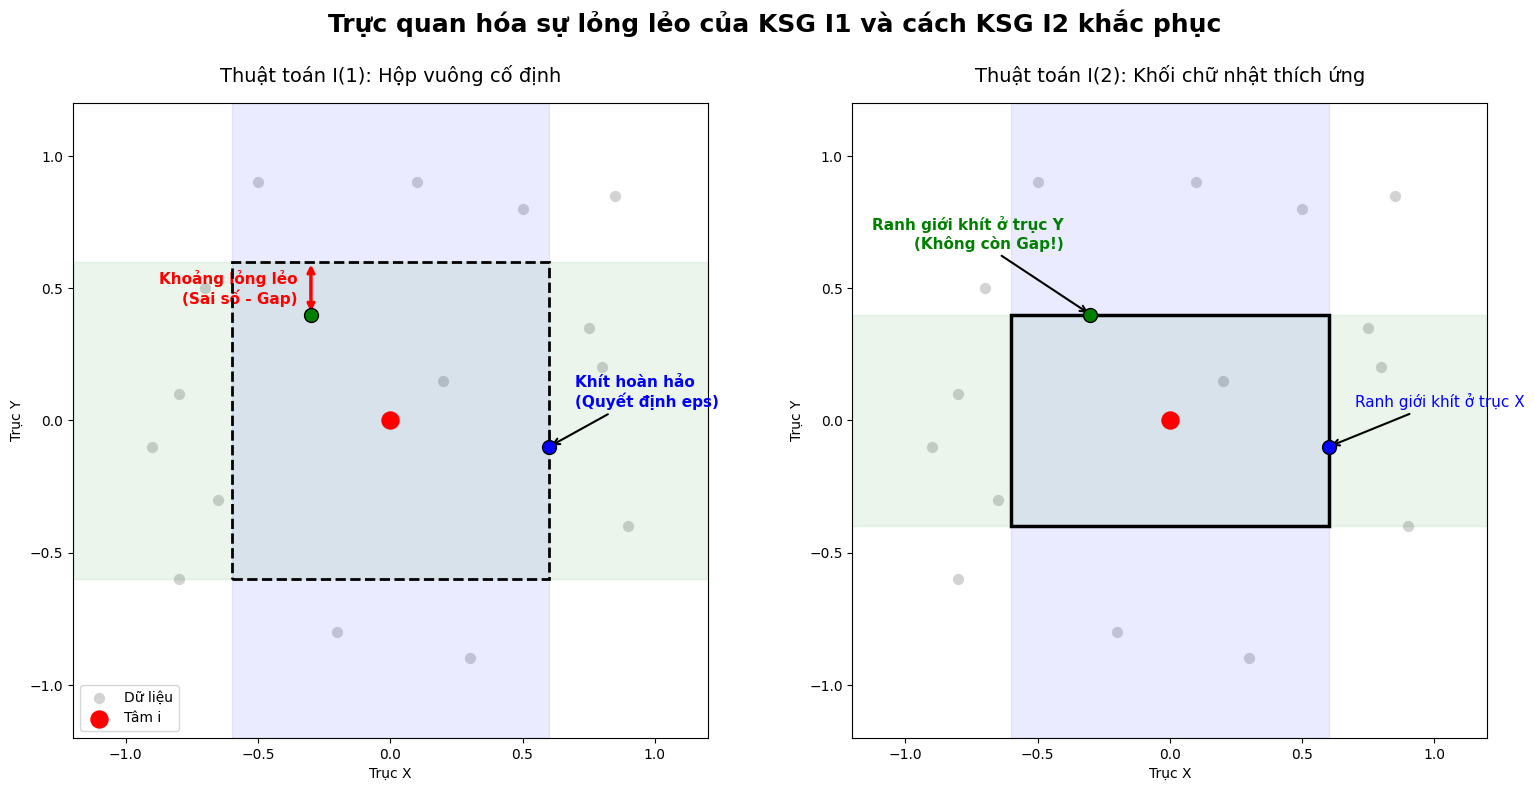

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_ksg_approximations():
    # ==========================================
    # 1. TẠO DỮ LIỆU CÓ CHỦ ĐÍCH (MOCK DATA)
    # ==========================================
    center = np.array([0.0, 0.0])
    
    # Thiết lập 3 điểm láng giềng k=3
    n1 = np.array([0.2, 0.15])
    # Điểm n2 quyết định ranh giới trục Y (Tọa độ Y cao nhất trong số 3 láng giềng)
    n2 = np.array([-0.3, 0.4])   
    # Điểm n3 là điểm láng giềng thứ 3, quyết định Maximum Norm (eps/2 = 0.6 trên trục X)
    n3 = np.array([0.6, -0.1])   
    
    # Tạo các điểm dữ liệu nhiễu xung quanh (đảm bảo nằm ngoài hộp vuông eps/2 = 0.6)
    noise = np.array([
        [0.8, 0.2], [-0.7, 0.5], [0.1, 0.9], [-0.2, -0.8],
        [0.9, -0.4], [-0.8, -0.6], [0.5, 0.8], [-0.5, 0.9],
        [0.85, 0.85], [-0.9, -0.1], [0.3, -0.9], [-0.65, -0.3],
        [0.75, 0.35], [-0.8, 0.1]
    ])
    
    data = np.vstack([center, n1, n2, n3, noise])
    
    # Tính toán thông số KSG
    # k=3, max norm được quyết định bởi n3 (0.6)
    eps_half = 0.6 
    
    # Cho thuật toán I2: Ranh giới khít theo từng trục của 3 điểm láng giềng
    neighbors = np.vstack([n1, n2, n3])
    eps_x_half = np.max(np.abs(neighbors[:, 0])) # = 0.6 (do n3)
    eps_y_half = np.max(np.abs(neighbors[:, 1])) # = 0.4 (do n2)

    # ==========================================
    # SETUP ĐỒ THỊ
    # ==========================================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    fig.suptitle('Trực quan hóa sự lỏng lẻo của KSG I1 và cách KSG I2 khắc phục', fontsize=18, fontweight='bold')

    # ==========================================
    # SUBPLOT 1: THUẬT TOÁN I1 (HỘP VUÔNG)
    # ==========================================
    ax1.scatter(data[:, 0], data[:, 1], color='lightgray', s=50, label='Dữ liệu')
    ax1.scatter(center[0], center[1], color='red', s=150, zorder=5, label='Tâm i')

    # Vẽ hộp vuông nét đứt
    rect1 = plt.Rectangle((-eps_half, -eps_half), 2*eps_half, 2*eps_half, 
                          fill=False, edgecolor='black', linestyle='--', linewidth=2, zorder=4)
    ax1.add_patch(rect1)

    # Vẽ dải băng chiếu (shaded stripes)
    ax1.axvspan(-eps_half, eps_half, color='blue', alpha=0.08)
    ax1.axhspan(-eps_half, eps_half, color='green', alpha=0.08)

    # Highlight điểm n3 (Khít hoàn hảo trên trục X)
    ax1.scatter(n3[0], n3[1], color='blue', s=100, edgecolor='black', zorder=6)
    ax1.annotate('Khít hoàn hảo\n(Quyết định eps)', xy=(n3[0], n3[1]), xytext=(n3[0] + 0.1, n3[1] + 0.15),
                 arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5), fontsize=11, color='blue', fontweight='bold')

    # Highlight điểm n2 & VẼ KHOẢNG LỎNG LẺO (GAP)
    ax1.scatter(n2[0], n2[1], color='green', s=100, edgecolor='black', zorder=6)
    
    # Mũi tên 2 chiều màu đỏ thể hiện GAP
    ax1.annotate('', xy=(n2[0], eps_half), xytext=(n2[0], n2[1]),
                 arrowprops=dict(arrowstyle='<->', color='red', lw=2.5))
    ax1.text(n2[0] - 0.05, (n2[1] + eps_half) / 2, 'Khoảng lỏng lẻo\n(Sai số - Gap)', 
             color='red', ha='right', va='center', fontsize=11, fontweight='bold')

    ax1.set_xlim(-1.2, 1.2)
    ax1.set_ylim(-1.2, 1.2)
    ax1.set_aspect('equal')
    ax1.set_title("Thuật toán I(1): Hộp vuông cố định", fontsize=14, pad=15)
    ax1.set_xlabel("Trục X")
    ax1.set_ylabel("Trục Y")
    ax1.legend(loc='lower left')

    # ==========================================
    # SUBPLOT 2: THUẬT TOÁN I2 (KHỐI CHỮ NHẬT)
    # ==========================================
    ax2.scatter(data[:, 0], data[:, 1], color='lightgray', s=50)
    ax2.scatter(center[0], center[1], color='red', s=150, zorder=5)

    # Vẽ Hình Chữ Nhật khít khìn khịt
    rect2 = plt.Rectangle((-eps_x_half, -eps_y_half), 2*eps_x_half, 2*eps_y_half, 
                          fill=False, edgecolor='black', linewidth=2.5, zorder=4)
    ax2.add_patch(rect2)

    # Vẽ dải băng chiếu theo kích thước chữ nhật
    ax2.axvspan(-eps_x_half, eps_x_half, color='blue', alpha=0.08)
    ax2.axhspan(-eps_y_half, eps_y_half, color='green', alpha=0.08)

    # Highlight cả 2 điểm quyết định ranh giới
    ax2.scatter(n3[0], n3[1], color='blue', s=100, edgecolor='black', zorder=6)
    ax2.scatter(n2[0], n2[1], color='green', s=100, edgecolor='black', zorder=6)

    # Ghi chú độ khít hoàn hảo
    ax2.annotate('Ranh giới khít ở trục X', xy=(n3[0], n3[1]), xytext=(n3[0] + 0.1, n3[1] + 0.15),
                 arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5), fontsize=11, color='blue')
    
    ax2.annotate('Ranh giới khít ở trục Y\n(Không còn Gap!)', xy=(n2[0], n2[1]), xytext=(n2[0] - 0.1, n2[1] + 0.25),
                 arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5), fontsize=11, color='green', fontweight='bold', ha='right')

    ax2.set_xlim(-1.2, 1.2)
    ax2.set_ylim(-1.2, 1.2)
    ax2.set_aspect('equal')
    ax2.set_title("Thuật toán I(2): Khối chữ nhật thích ứng", fontsize=14, pad=15)
    ax2.set_xlabel("Trục X")
    ax2.set_ylabel("Trục Y")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

if __name__ == "__main__":
    visualize_ksg_approximations()

Đang khởi tạo dữ liệu và bơm nhiễu...
Đang tính toán Thông tin tương hỗ cho các độ trễ tau...
-> TÌM THẤY: Độ trễ tối ưu tau = 16 (Tại MI = 1.1070)


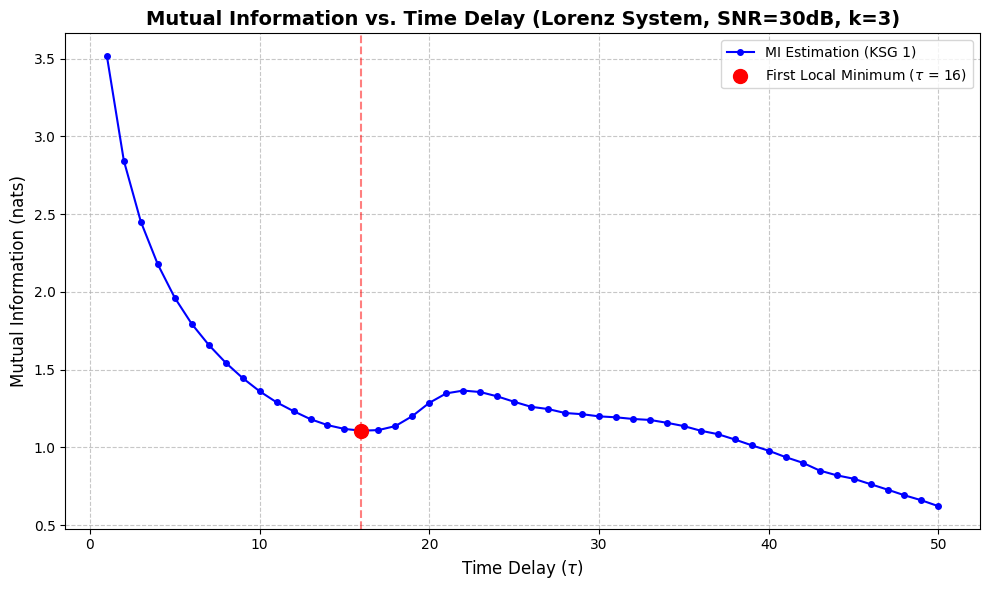

In [3]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.special import digamma
from scipy.signal import argrelextrema

# Khai báo đường dẫn module gốc (Đoạn code của bạn)
sys.path.append(os.path.abspath(".."))
try:
    from core_ntsa.generators import simulate_lorenz
    from core_ntsa.noise_tools import add_white_noise
except ImportError:
    # Đoạn mock data tạm thời nếu thiếu module cục bộ để bạn dễ chạy test
    def simulate_lorenz(t_span=100.0, dt=0.01):
        from scipy.integrate import odeint
        def lorenz_deriv(xyz, t, sigma=10.0, beta=8./3, rho=28.0):
            x, y, z = xyz
            return [sigma * (y - x), x * (rho - z) - y, x * y - beta * z]
        t = np.arange(0, t_span, dt)
        return odeint(lorenz_deriv, [1.0, 1.0, 1.0], t).T
    
    def add_white_noise(data, snr_db):
        sig_pow = np.mean(data**2)
        noise_pow = sig_pow / (10 ** (snr_db / 10))
        return data + np.random.normal(0, np.sqrt(noise_pow), len(data))

# =====================================================================
# 1. ĐẦU VÀO (INPUT)
# =====================================================================
print("Đang khởi tạo dữ liệu và bơm nhiễu...")
lorenz_data = simulate_lorenz(t_span=100.0, dt=0.01)
clean_x = lorenz_data[0]
noisy_x = clean_x
N_T = len(noisy_x)


# =====================================================================
# 2. HÀM LÕI: ƯỚC LƯỢNG MI BẰNG THUẬT TOÁN KSG 1
# =====================================================================
def ksg_mi_1(x, y, k=3):
    """
    Tính Mutual Information bằng KSG Algorithm 1.
    Tích hợp các kỹ thuật chống trùng lặp và tối ưu hóa cKDTree.
    """
    # a. Chuẩn hóa phương sai (Unit variance)
    x = (x - np.mean(x)) / np.std(x)
    y = (y - np.mean(y)) / np.std(y)

    # b. Tuyệt chiêu KSG: Bơm nhiễu siêu nhỏ phá vỡ Degeneracy
    x += np.random.normal(0, 1e-10, size=x.shape)
    y += np.random.normal(0, 1e-10, size=y.shape)

    N = len(x)
    z = np.column_stack((x, y))

    # c. Tìm láng giềng k trong Không gian tổng (Chuẩn cực đại p=np.inf)
    tree_z = cKDTree(z)
    eps_half, _ = tree_z.query(z, k=k+1, p=np.inf)
    eps_half = eps_half[:, -1] # Lấy khoảng cách tới láng giềng thứ k

    # d. Chiếu và đếm (Sử dụng strictly less than bằng cách trừ 1e-15)
    eps_strict = np.maximum(eps_half - 1e-15, 0)

    tree_x = cKDTree(x.reshape(-1, 1))
    tree_y = cKDTree(y.reshape(-1, 1))

    # query_ball_point trả về mảng chứa số lượng điểm lọt vào bóng chiếu.
    # Vì hàm này tự động đếm cả điểm tâm, nên kết quả chính là (n_x + 1) và (n_y + 1)
    nx_plus_1 = tree_x.query_ball_point(x.reshape(-1, 1), eps_strict, p=np.inf, return_length=True)
    ny_plus_1 = tree_y.query_ball_point(y.reshape(-1, 1), eps_strict, p=np.inf, return_length=True)

    # e. Công thức KSG 1 (Eq. 8)
    mi = digamma(k) - np.mean(digamma(nx_plus_1) + digamma(ny_plus_1)) + digamma(N)
    return max(0, mi)


# =====================================================================
# 3. QUÉT ĐỘ TRỄ THỜI GIAN (TIME LAG ESTIMATION)
# =====================================================================
print("Đang tính toán Thông tin tương hỗ cho các độ trễ tau...")
max_tau = 50  # Số lượng độ trễ cần quét
taus = np.arange(1, max_tau + 1)
mi_values = []

# Chọn k=3 hoặc 4 để cân bằng bias-variance như KSG khuyến nghị
k_neighbors = 3 

for tau in taus:
    # Trượt dữ liệu để tạo x(t) và x(t + tau)
    x_t = noisy_x[:-tau]
    x_t_plus_tau = noisy_x[tau:]
    
    # Tính MI cho cặp trễ này
    mi = ksg_mi_1(x_t, x_t_plus_tau, k=k_neighbors)
    mi_values.append(mi)

mi_values = np.array(mi_values)

# Tự động tìm Cực tiểu cục bộ đầu tiên (First Local Minimum)
local_minima_idx = argrelextrema(mi_values, np.less)[0]

if len(local_minima_idx) > 0:
    optimal_tau_idx = local_minima_idx[0]
    optimal_tau = taus[optimal_tau_idx]
    min_mi_val = mi_values[optimal_tau_idx]
    print(f"-> TÌM THẤY: Độ trễ tối ưu tau = {optimal_tau} (Tại MI = {min_mi_val:.4f})")
else:
    optimal_tau = None
    print("-> CẢNH BÁO: Không tìm thấy cực tiểu cục bộ. Thử tăng max_tau.")


# =====================================================================
# 4. TRỰC QUAN HÓA KẾT QUẢ
# =====================================================================
plt.figure(figsize=(10, 6))
plt.plot(taus, mi_values, marker='o', linestyle='-', color='b', markersize=4, label='MI Estimation (KSG 1)')

if optimal_tau is not None:
    plt.scatter(optimal_tau, min_mi_val, color='red', s=100, zorder=5, 
                label=f'First Local Minimum ($\\tau$ = {optimal_tau})')
    plt.axvline(x=optimal_tau, color='r', linestyle='--', alpha=0.5)

plt.title(f"Mutual Information vs. Time Delay (Lorenz System, SNR=30dB, k={k_neighbors})", fontsize=14, fontweight='bold')
plt.xlabel("Time Delay ($\\tau$)", fontsize=12)
plt.ylabel("Mutual Information (nats)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


Đang tái tạo không gian pha theo định lý Takens...
-> Chiều nhúng (m)  : 3
-> Độ trễ (tau)     : 16


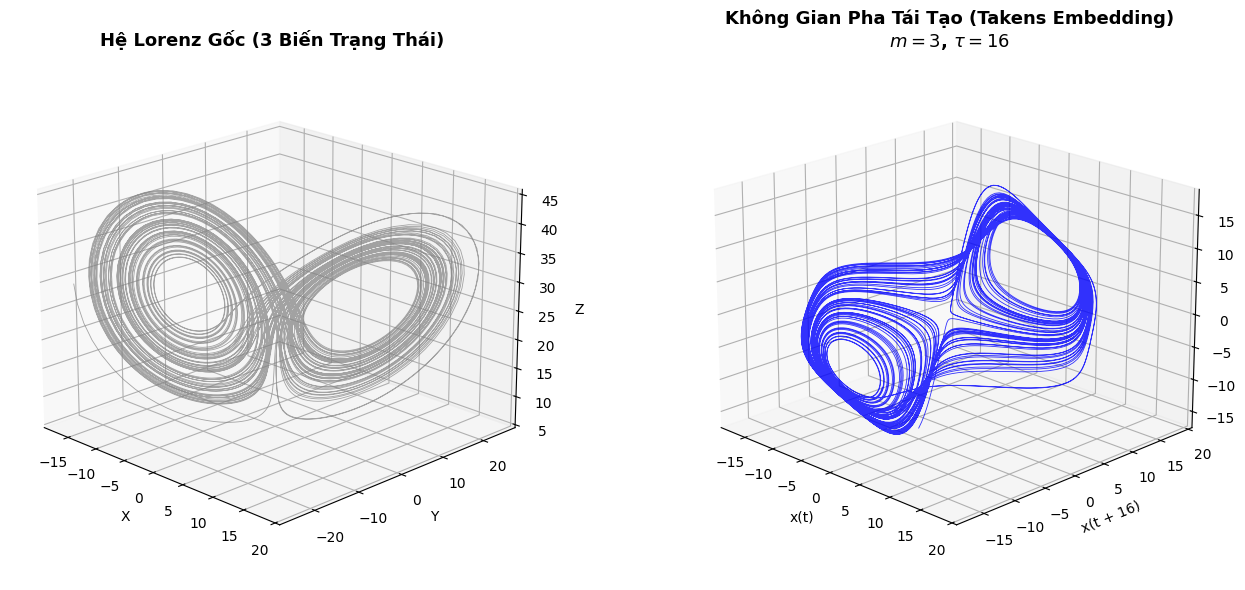

In [4]:
# =====================================================================
# 5. TÁI TẠO KHÔNG GIAN PHA (PHASE SPACE RECONSTRUCTION)
# =====================================================================
if optimal_tau is not None:
    print(f"\nĐang tái tạo không gian pha theo định lý Takens...")
    print(f"-> Chiều nhúng (m)  : 3")
    print(f"-> Độ trễ (tau)     : {optimal_tau}")
    
    # Chọn m = 3 cho hệ động lực Lorenz
    m = 3
    
    # Tính toán số lượng điểm hợp lệ sau khi trượt khung thời gian
    N_embed = N_T - (m - 1) * optimal_tau
    
    # Khởi tạo và xây dựng ma trận Không gian pha (Phase Space)
    # Cấu trúc: Cột 1: x(t), Cột 2: x(t + tau), Cột 3: x(t + 2*tau)
    phase_space = np.zeros((N_embed, m))
    for i in range(m):
        phase_space[:, i] = noisy_x[i * optimal_tau : i * optimal_tau + N_embed]
        
    # =================================================================
    # TRỰC QUAN HÓA: SO SÁNH HỆ GỐC VÀ HỆ TÁI TẠO
    # =================================================================
    fig = plt.figure(figsize=(14, 6))
    
    # --- Đồ thị 1: Hệ Lorenz gốc (Từ 3 biến độc lập nguyên bản) ---
    ax1 = fig.add_subplot(121, projection='3d')
    # Giả định lorenz_data có cấu trúc (3, N) tương ứng (x, y, z)
    ax1.plot(lorenz_data[0], lorenz_data[1], lorenz_data[2], 
             color='gray', lw=0.6, alpha=0.7)
    ax1.set_title("Hệ Lorenz Gốc (3 Biến Trạng Thái)", fontsize=13, fontweight='bold')
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    ax1.set_zlabel("Z")
    
    # --- Đồ thị 2: Không gian pha tái tạo (Từ 1 biến noisy_x duy nhất) ---
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.plot(phase_space[:, 0], phase_space[:, 1], phase_space[:, 2], 
             color='blue', lw=0.6, alpha=0.8)
    
    ax2.set_title(f"Không Gian Pha Tái Tạo (Takens Embedding)\n$m={m}$, $\\tau={optimal_tau}$", 
                  fontsize=13, fontweight='bold')
    ax2.set_xlabel("x(t)")
    ax2.set_ylabel(f"x(t + {optimal_tau})")
    ax2.set_zlabel(f"x(t + {2*optimal_tau})")
    
    # Tinh chỉnh góc nhìn mặc định cho dễ quan sát hình cánh bướm
    ax1.view_init(elev=20, azim=-45)
    ax2.view_init(elev=20, azim=-45)
    
    plt.tight_layout()
    plt.show()
else:
    print("\nBỏ qua bước tái tạo không gian pha do chưa tìm được tau hợp lệ.")

1. Đang mô phỏng hệ Lorenz và thêm nhiễu trắng (SNR=30dB)...
2. Đang quét Thông tin tương hỗ (MI) để tìm độ trễ tau tối ưu...
-> THÀNH CÔNG: Tìm thấy Time Lag tối ưu tau = 15
3. Đang tái tạo Không gian pha 3D (Takens Embedding)...


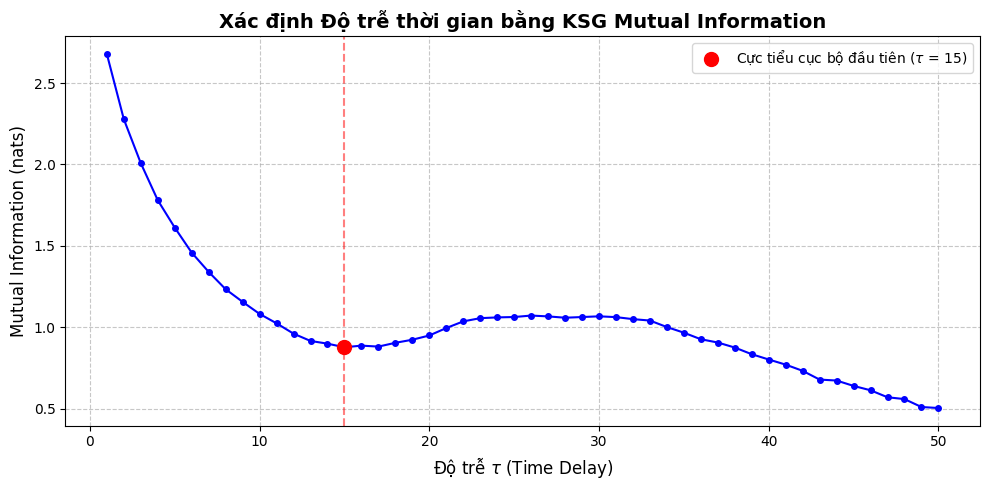

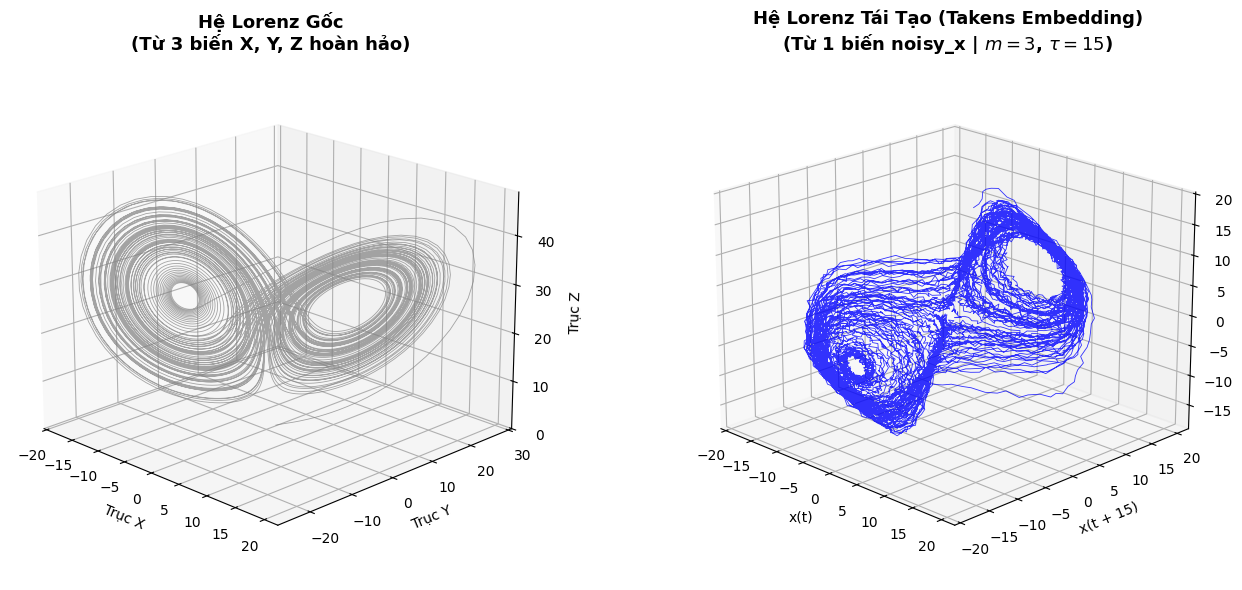


-> Hoàn tất quy trình phân tích!


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.special import digamma
from scipy.signal import argrelextrema
from scipy.integrate import odeint

# =====================================================================
# 1. HÀM TẠO DỮ LIỆU (MÔ PHỎNG LORENZ & BƠM NHIỄU)
# =====================================================================
def simulate_lorenz(t_span=100.0, dt=0.01):
    """Mô phỏng hệ động lực hỗn mang Lorenz."""
    def lorenz_deriv(xyz, t, sigma=10.0, beta=8./3, rho=28.0):
        x, y, z = xyz
        return [sigma * (y - x), x * (rho - z) - y, x * y - beta * z]
    
    t = np.arange(0, t_span, dt)
    # Trả về ma trận (3, N) tương ứng với các trục X, Y, Z
    return odeint(lorenz_deriv, [1.0, 1.0, 1.0], t).T

def add_white_noise(data, snr_db):
    """Bơm nhiễu trắng theo tỷ lệ Tín hiệu/Nhiễu (SNR)."""
    sig_pow = np.mean(data**2)
    noise_pow = sig_pow / (10 ** (snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_pow), len(data))
    return data + noise

# =====================================================================
# 2. HÀM LÕI: ƯỚC LƯỢNG MI BẰNG THUẬT TOÁN KSG 1
# =====================================================================
def ksg_mi_1(x, y, k=3):
    """Tính Mutual Information bằng KSG Algorithm 1 (Chuẩn cực đại)."""
    # Chuẩn hóa phương sai (Unit variance)
    x = (x - np.mean(x)) / np.std(x)
    y = (y - np.mean(y)) / np.std(y)

    # Tuyệt chiêu KSG: Bơm nhiễu siêu nhỏ phá vỡ Degeneracy (Trùng lặp dữ liệu)
    x += np.random.normal(0, 1e-10, size=x.shape)
    y += np.random.normal(0, 1e-10, size=y.shape)

    N = len(x)
    z = np.column_stack((x, y))

    # Tìm láng giềng k trong Không gian tổng bằng cKDTree
    tree_z = cKDTree(z)
    eps_half, _ = tree_z.query(z, k=k+1, p=np.inf)
    eps_half = eps_half[:, -1] # Lấy khoảng cách tới láng giềng k

    # Ép khoảng cách giới hạn nghiêm ngặt
    eps_strict = np.maximum(eps_half - 1e-15, 0)

    # Chiếu và đếm (hàm query_ball_point tự động đếm cả điểm tâm)
    tree_x = cKDTree(x.reshape(-1, 1))
    tree_y = cKDTree(y.reshape(-1, 1))
    nx_plus_1 = tree_x.query_ball_point(x.reshape(-1, 1), eps_strict, p=np.inf, return_length=True)
    ny_plus_1 = tree_y.query_ball_point(y.reshape(-1, 1), eps_strict, p=np.inf, return_length=True)

    # Công thức số (8) của bài báo KSG (2004)
    mi = digamma(k) - np.mean(digamma(nx_plus_1) + digamma(ny_plus_1)) + digamma(N)
    return max(0, mi)

# =====================================================================
# 3. CHƯƠNG TRÌNH CHÍNH (MAIN PIPELINE)
# =====================================================================
if __name__ == "__main__":
    print("1. Đang mô phỏng hệ Lorenz và thêm nhiễu trắng (SNR=30dB)...")
    lorenz_data = simulate_lorenz(t_span=100.0, dt=0.01)
    clean_x = lorenz_data[0] # Chỉ lấy trục X để phân tích
    noisy_x = add_white_noise(clean_x, snr_db=30.0)
    N_T = len(noisy_x)

    print("2. Đang quét Thông tin tương hỗ (MI) để tìm độ trễ tau tối ưu...")
    max_tau = 50
    taus = np.arange(1, max_tau + 1)
    mi_values = []
    k_neighbors = 3

    for tau in taus:
        x_t = noisy_x[:-tau]
        x_t_plus_tau = noisy_x[tau:]
        mi = ksg_mi_1(x_t, x_t_plus_tau, k=k_neighbors)
        mi_values.append(mi)

    mi_values = np.array(mi_values)

    # Tìm cực tiểu cục bộ đầu tiên
    local_minima_idx = argrelextrema(mi_values, np.less)[0]
    if len(local_minima_idx) > 0:
        optimal_tau_idx = local_minima_idx[0]
        optimal_tau = taus[optimal_tau_idx]
        min_mi_val = mi_values[optimal_tau_idx]
        print(f"-> THÀNH CÔNG: Tìm thấy Time Lag tối ưu tau = {optimal_tau}")
    else:
        optimal_tau = 15 # Giá trị fallback an toàn cho hệ Lorenz nếu nhiễu quá mạnh
        print(f"-> CẢNH BÁO: Không tìm thấy cực tiểu cục bộ. Dùng giá trị fallback tau = {optimal_tau}")

    # =====================================================================
    # 4. TÁI TẠO KHÔNG GIAN PHA (PHASE SPACE RECONSTRUCTION)
    # =====================================================================
    print("3. Đang tái tạo Không gian pha 3D (Takens Embedding)...")
    m = 3 # Chiều nhúng cho hệ Lorenz
    N_embed = N_T - (m - 1) * optimal_tau
    phase_space = np.zeros((N_embed, m))
    for i in range(m):
        phase_space[:, i] = noisy_x[i * optimal_tau : i * optimal_tau + N_embed]

    # =====================================================================
    # 5. TRỰC QUAN HÓA (VISUALIZATION)
    # =====================================================================
    # Đồ thị 1: Sự phụ thuộc của MI vào Time Lag
    fig1 = plt.figure(figsize=(10, 5))
    plt.plot(taus, mi_values, marker='o', linestyle='-', color='b', markersize=4)
    if len(local_minima_idx) > 0:
        plt.scatter(optimal_tau, min_mi_val, color='red', s=100, zorder=5, 
                    label=f'Cực tiểu cục bộ đầu tiên ($\\tau$ = {optimal_tau})')
        plt.axvline(x=optimal_tau, color='r', linestyle='--', alpha=0.5)
    plt.title(f"Xác định Độ trễ thời gian bằng KSG Mutual Information", fontsize=14, fontweight='bold')
    plt.xlabel("Độ trễ $\\tau$ (Time Delay)", fontsize=12)
    plt.ylabel("Mutual Information (nats)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()

    # Đồ thị 2: So sánh Hệ nguyên bản và Hệ tái tạo
    fig2 = plt.figure(figsize=(14, 6))
    
    # Bên trái: Lorenz gốc (3 biến X, Y, Z sạch)
    ax1 = fig2.add_subplot(121, projection='3d')
    ax1.plot(lorenz_data[0], lorenz_data[1], lorenz_data[2], color='gray', lw=0.6, alpha=0.7)
    ax1.set_title("Hệ Lorenz Gốc\n(Từ 3 biến X, Y, Z hoàn hảo)", fontsize=13, fontweight='bold')
    ax1.set_xlabel("Trục X")
    ax1.set_ylabel("Trục Y")
    ax1.set_zlabel("Trục Z")
    ax1.view_init(elev=20, azim=-45)

    # Bên phải: Lorenz tái tạo (Chỉ từ 1 biến noisy_x)
    ax2 = fig2.add_subplot(122, projection='3d')
    ax2.plot(phase_space[:, 0], phase_space[:, 1], phase_space[:, 2], color='blue', lw=0.6, alpha=0.8)
    ax2.set_title(f"Hệ Lorenz Tái Tạo (Takens Embedding)\n(Từ 1 biến noisy_x | $m={m}$, $\\tau={optimal_tau}$)", 
                  fontsize=13, fontweight='bold')
    ax2.set_xlabel("x(t)")
    ax2.set_ylabel(f"x(t + {optimal_tau})")
    ax2.set_zlabel(f"x(t + {2*optimal_tau})")
    ax2.view_init(elev=20, azim=-45)

    plt.tight_layout()
    plt.show()
    print("\n-> Hoàn tất quy trình phân tích!")